In [92]:
import warnings
warnings.filterwarnings('ignore')


In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df=pd.read_csv("preprocessing_dataset.csv")
df1=df.copy()
df2=df.copy()
df3=df.copy()
df4=df.copy()
df5=df.copy()
df6=df.copy()
df7=df.copy()

In [95]:
df.head()

,Name,Age,Gender,Salary,Department
0,Alice,25.0,F,50000.0,HR
1,Bob,30.0,M,60000.0,Finance
2,Charlie,NaN,M,55000.0,IT
3,David,40.0,M,58000.0,HR
4,Eve,22.0,F,52000.0,IT


In [96]:
df.tail()

,Name,Age,Gender,Salary,Department
5,Frank,35.0,NaN,61000.0,Finance
6,Grace,120.0,F,NaN,Finance
7,Henry,28.0,M,59000.0,HR
8,Ivy,29.0,F,63000.0,IT
9,Jack,27.0,M,62000.0,Finance


In [97]:
df.describe()

,Age,Salary
count,9.000000,9.000000
mean,39.555556,57777.777778
std,30.631320,4521.553322
min,22.000000,50000.000000
25%,27.000000,55000.000000
50%,29.000000,59000.000000
75%,35.000000,61000.000000
max,120.000000,63000.000000


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        10 non-null     object 
 1   Age         9 non-null      float64
 2   Gender      9 non-null      object 
 3   Salary      9 non-null      float64
 4   Department  10 non-null     object 
dtypes: float64(2), object(3)
memory usage: 532.0+ bytes


In [99]:
df.shape

(10, 5)

In [100]:
df.size

50

**IDENTIFYING MISSING VALUES**

In [101]:
df.isnull().sum()

Name          0
Age           1
Gender        1
Salary        1
Department    0
dtype: int64

MIISINGNO ==> Used to identify the missing value in the bar graph

In [102]:
!pip install missingno

<Axes: >

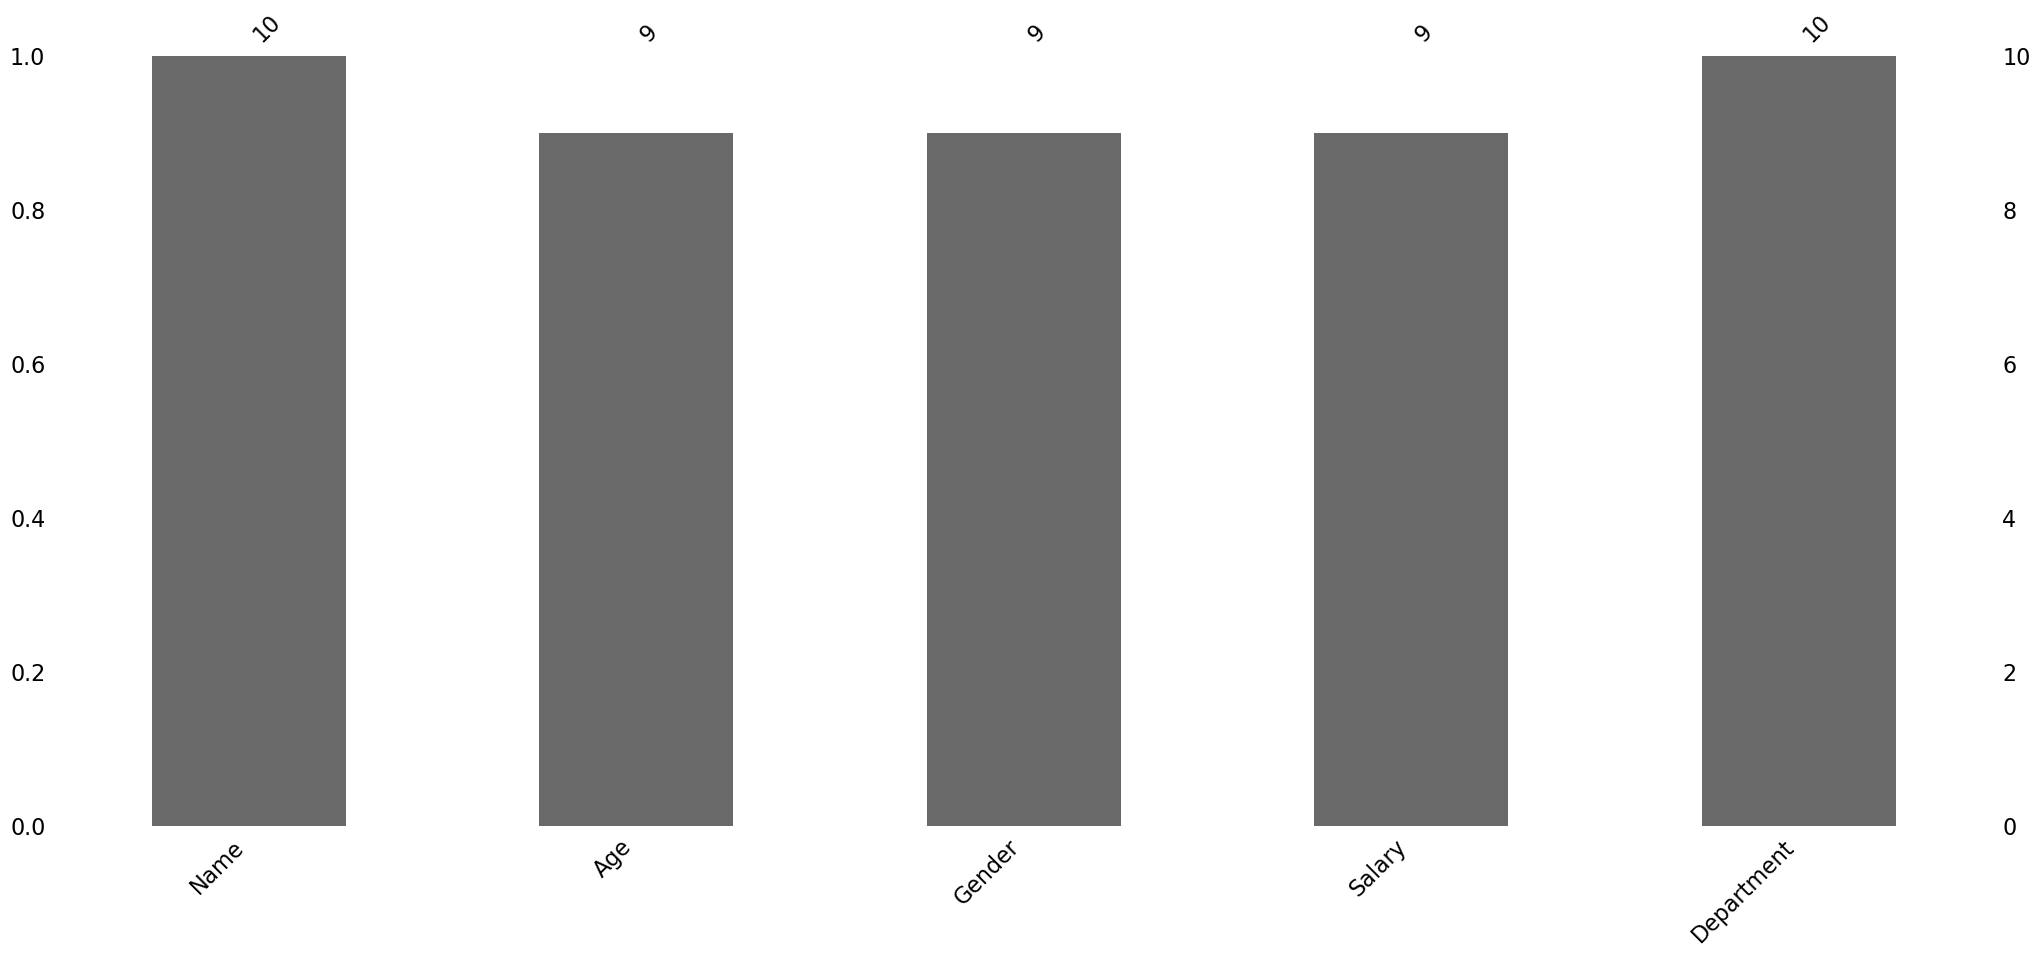

In [103]:
import missingno as mso
mso.bar(df)

<Axes: >

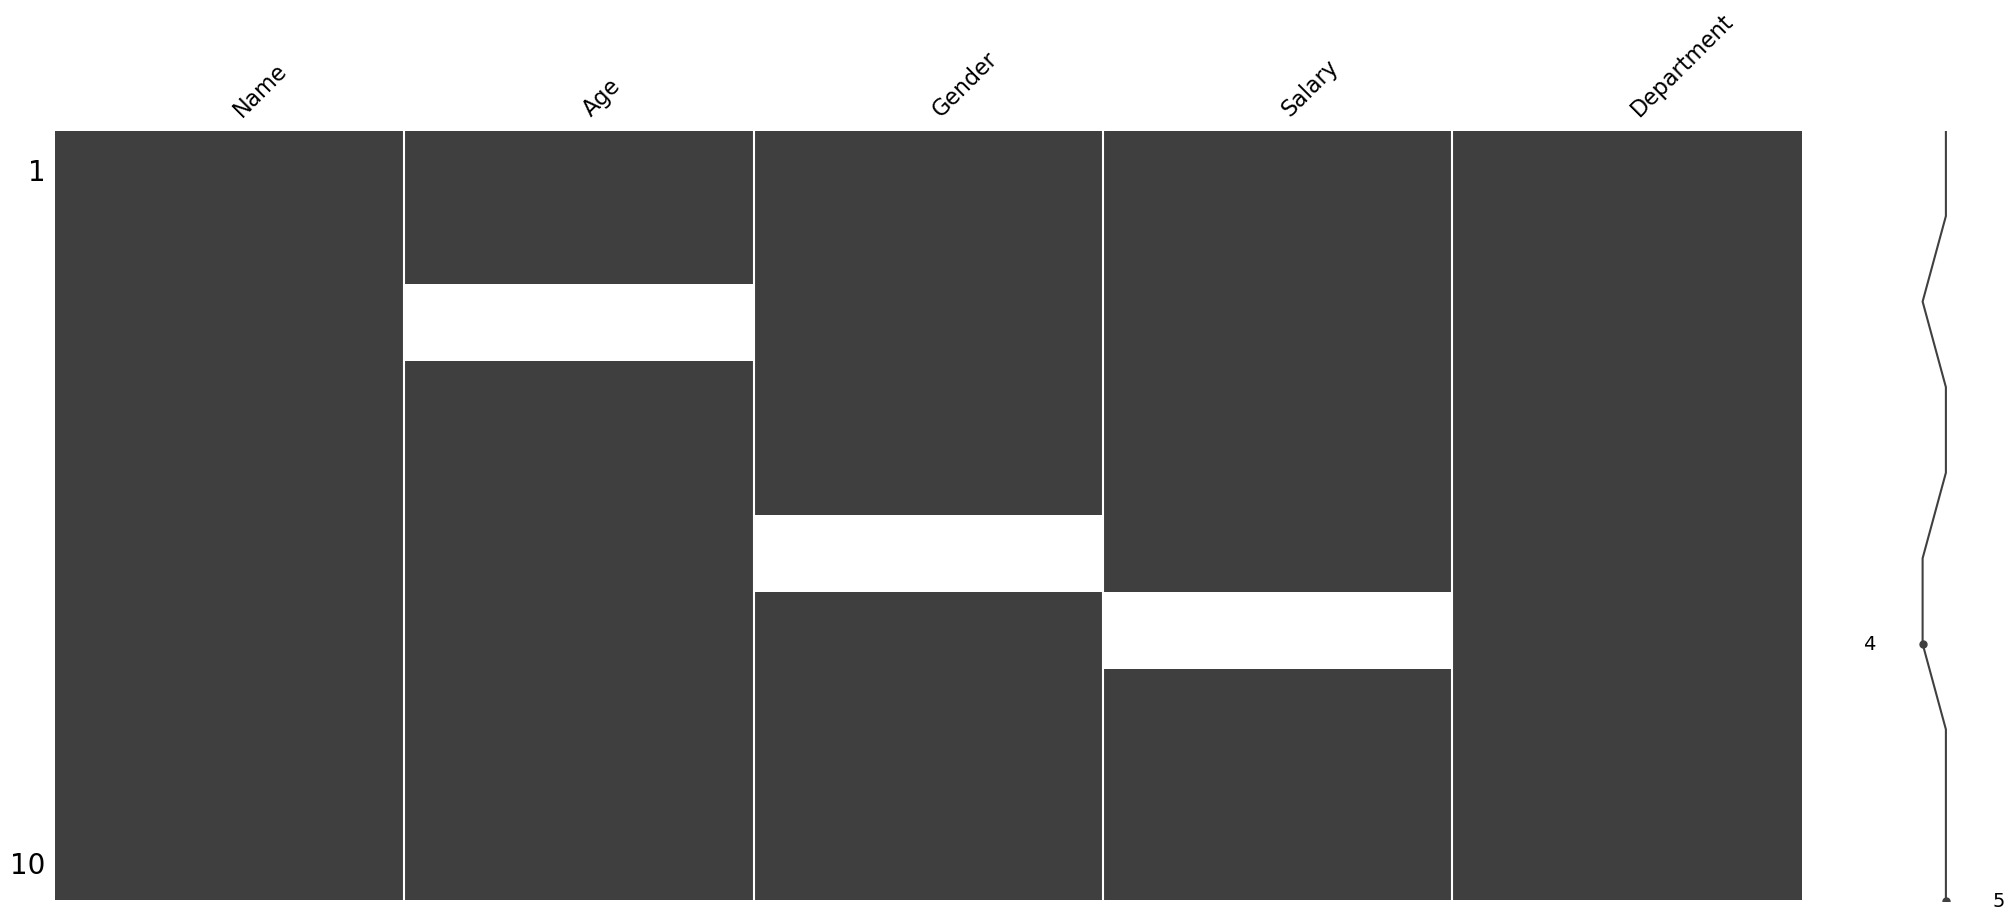

In [104]:
mso.matrix(df) #matrix==> used to identify the missing value in that specific row

**HEATMAP ==> It is also used to identify missing values**

<Axes: >

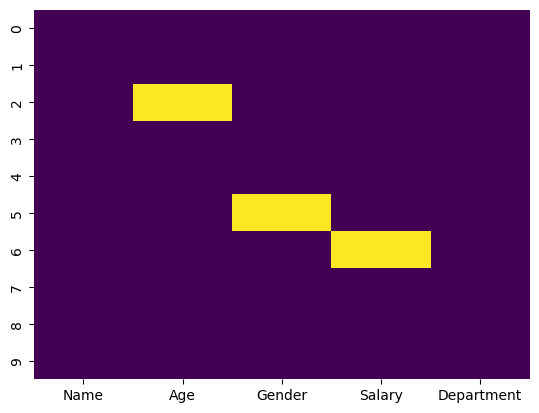

In [105]:
sns.heatmap(df.isnull(),cmap="viridis",cbar=False)

**CONTINUOUS LABELS** ==> there is a specific range available (eg:between 1 and 2 there is 1.1,1.2...) EG:Height
**DISCRETE LABELS** ==> there is no specifi range available EG:No.of students in a class

**HANDLING MISSING VALUES**

In [106]:
"""If more null values available in a column -> remove that column
--> mean - continuous labels , no outlier , normal distribution
--> median - discrete lables , outlier , skewed data
--> mode - categorical labels """

'If more null values available in a column -> remove that column\n--> mean - continuous labels , no outlier , normal distribution\n--> median - discrete lables , outlier , skewed data\n--> mode - categorical labels '

In [107]:
#df["Age"]=df["Age"].fillna(df["Age"].mean())
df["Age"].fillna(df["Age"].mean(),inplace=True)  #inplace is used to update in the original data
df["Salary"].fillna(df["Salary"].mean(),inplace=True) 

In [108]:
df["Gender"].fillna(df["Gender"].mode()[0],inplace=True)

In [109]:
df.isnull().sum()

Name          0
Age           0
Gender        0
Salary        0
Department    0
dtype: int64

**SIMPLE IMPUTER**

**Simple imputer replaces missing values by using mean,median,most_frequent(categorical),constant(replace missing value with the fixed value that you provide)**

In [110]:
from sklearn.impute import SimpleImputer

In [111]:
imp=SimpleImputer(strategy="median")
df1[["Age"]]=imp.fit_transform(df1[["Age"]])
df1[["Salary"]]=imp.fit_transform(df1[["Salary"]])

In [112]:
imp=SimpleImputer(strategy="most_frequent")
df1[["Gender"]]=imp.fit_transform(df1[["Gender"]])

In [113]:
""" salary_imputer=SimpleImputer(strategy='constant',fill_value=0)
df[['salary']]=salary_imputer.fit_transform(df[['salary']])"""

" salary_imputer=SimpleImputer(strategy='constant',fill_value=0)\ndf[['salary']]=salary_imputer.fit_transform(df[['salary']])"

**IDENTIFYING OUTLIERS**

<Axes: ylabel='Age'>

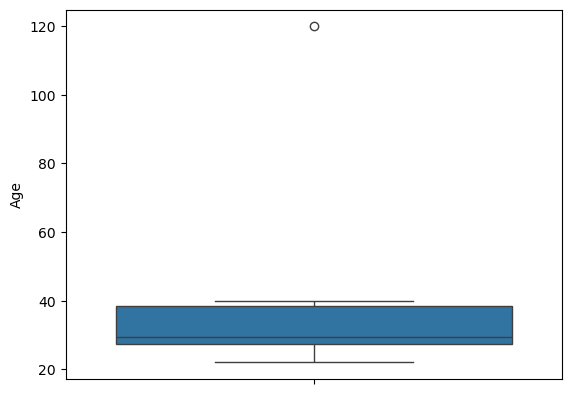

In [114]:
#using boxplot
sns.boxplot(df["Age"])

<Axes: xlabel='Age'>

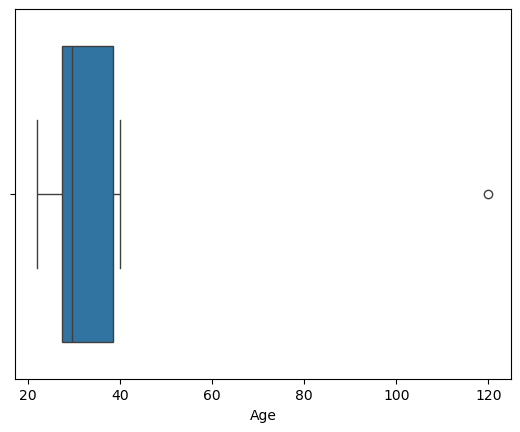

In [115]:
sns.boxplot(x=df["Age"])

**IQR --> Interquartile Range - data points outside the range considered as outliers**

In [116]:
q1=df["Age"].quantile(0.25)
q3=df["Age"].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outliers=df[(df["Age"]<lower_bound)|(df["Age"]>upper_bound)]
outliers

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


In [117]:
from scipy.stats import zscore  #zscore range -3 to 3

In [118]:
z_scores=zscore(df["Age"])
df[np.abs(z_scores)>2.5]     

,Name,Age,Gender,Salary,Department
6,Grace,120.0,F,57777.777778,Finance


**ISOLATIONFOREST**

In [119]:
from sklearn.ensemble import IsolationForest

In [120]:
iso=IsolationForest(contamination=0.1)
df["outlier"]=iso.fit_predict(df[["Age","Salary"]])
df[df["outlier"]==-1]

,Name,Age,Gender,Salary,Department,outlier
6,Grace,120.0,F,57777.777778,Finance,-1


**HANDLING OUTLIERS**

**WINSORIZATION --> is a technique to handle outlier by replacing them with upper and lower limit values insted of deleting them**

In [121]:
from scipy.stats.mstats import winsorize
df["Age_w"]=winsorize(df["Age"],limits=(0.3,0.3))
df["sala_w"]=winsorize(df["Salary"],limits=(0.05,0.05))
print(df)

      Name   Age Gender        Salary Department  outlier  Age_w        sala_w
0    Alice  28.0      F  50000.000000         HR        1   28.0  50000.000000
1      Bob  30.0      M  60000.000000    Finance        1   30.0  60000.000000
2  Charlie  35.0      M  55000.000000         IT        1   35.0  55000.000000
3    David  35.0      M  58000.000000         HR        1   35.0  58000.000000
4      Eve  28.0      F  52000.000000         IT        1   28.0  52000.000000
5    Frank  35.0      M  61000.000000    Finance        1   35.0  61000.000000
6    Grace  35.0      F  57777.777778    Finance       -1   35.0  57777.777778
7    Henry  28.0      M  59000.000000         HR        1   28.0  59000.000000
8      Ivy  29.0      F  63000.000000         IT        1   29.0  63000.000000
9     Jack  28.0      M  62000.000000    Finance        1   28.0  62000.000000


**LOG TRANSFORMATION --> mainly used to handle outlier, reduce skewness, make distributions normal**

In [122]:
#df["Age"]=df["Age"].fillna(df["Age"].mean())
df2["Age"].fillna(df2["Age"].mean(),inplace=True)  #inplace is used to update in the original data
df2["Salary"].fillna(df2["Salary"].mean(),inplace=True)
df2["Gender"].fillna(df2["Gender"].mode()[0],inplace=True)

In [123]:
df2[["Age_log","Salary_log"]]=np.log(df2[["Age","Salary"]])   #np.log ==> used for positive values
print(df2[["Age_log","Salary_log"]])

    Age_log  Salary_log
0  3.218876   10.819778
1  3.401197   11.002100
2  3.677706   10.915088
3  3.688879   10.968198
4  3.091042   10.858999
5  3.555348   11.018629
6  4.787492   10.964360
7  3.332205   10.985293
8  3.367296   11.050890
9  3.295837   11.034890


In [124]:
df2[["Age_log","Salary_log"]]=np.log1p(df2[["Age","Salary"]])   #np.log1p ==> used for 0 and negative values
print(df2[["Age_log","Salary_log"]])

    Age_log  Salary_log
0  3.258097   10.819798
1  3.433987   11.002117
2  3.702673   10.915107
3  3.713572   10.968216
4  3.135494   10.859018
5  3.583519   11.018646
6  4.795791   10.964377
7  3.367296   10.985310
8  3.401197   11.050906
9  3.332205   11.034906


**POWER TRANSFORMER --> Applies power log function(yeo-jhonson and box-cox) to handle outlier,reduce skewness, make data more gaussian like). It can handle both +ve and -ve values**

In [125]:
#df["Age"]=df["Age"].fillna(df["Age"].mean())
df3["Age"].fillna(df3["Age"].mean(),inplace=True)  #inplace is used to update in the original data
df3["Salary"].fillna(df3["Salary"].mean(),inplace=True)
df3["Gender"].fillna(df3["Gender"].mode()[0],inplace=True)

In [126]:
from sklearn.preprocessing import PowerTransformer

In [127]:
pt=PowerTransformer(method="yeo-johnson")
df3[["Age","Salary"]]=pt.fit_transform(df3[["Age","Salary"]])   #yeo-johnson is used for both +ve and -ve values
print(df3)

      Name       Age Gender    Salary Department
0    Alice -0.966514      F -1.651983         HR
1      Bob -0.100378      M  0.468100    Finance
2  Charlie  0.784877      M -0.829770         IT
3    David  0.812389      M -0.119688         HR
4      Eve -1.758521      F -1.369531         IT
5    Frank  0.445352      M  0.801322    Finance
6    Grace  1.987909      F -0.178982    Finance
7    Henry -0.396398      M  0.161683         HR
8      Ivy -0.241400      F  1.555656         IT
9     Jack -0.567315      M  1.163193    Finance


**BOX_COX --> It is used to handle outlier by tranforming data closer to noraml distibution. It is strictly for positive data**

In [128]:
#df["Age"]=df["Age"].fillna(df["Age"].mean())
df4["Age"].fillna(df4["Age"].mean(),inplace=True)  #inplace is used to update in the original data
df4["Salary"].fillna(df4["Salary"].mean(),inplace=True)
df4["Gender"].fillna(df4["Gender"].mode()[0],inplace=True)

In [129]:
pt=PowerTransformer(method="box-cox")
df4[["Age","Salary"]]=pt.fit_transform(df4[["Age","Salary"]])
print(df4)

      Name       Age Gender    Salary Department
0    Alice -0.965755      F -1.651983         HR
1      Bob -0.098076      M  0.468101    Finance
2  Charlie  0.783817      M -0.829770         IT
3    David  0.811174      M -0.119687         HR
4      Eve -1.764395      F -1.369532         IT
5    Frank  0.446024      M  0.801322    Finance
6    Grace  1.985336      F -0.178982    Finance
7    Henry -0.394000      M  0.161683         HR
8      Ivy -0.238976      F  1.555656         IT
9     Jack -0.565147      M  1.163193    Finance


**STANDARD SCALER --> preprocessing technique that standardize features 
Imagine two features:
Height (cm): 150–200
Income (₹): 10,000–100,000
Without scaling, Income dominates because of its larger numeric range.
With StandardScaler, both features are centered and scaled, so the model treats them fairly**

In [130]:
#df["Age"]=df["Age"].fillna(df["Age"].mean())
df5["Age"].fillna(df5["Age"].mean(),inplace=True)  #inplace is used to update in the original data
df5["Salary"].fillna(df5["Salary"].mean(),inplace=True)
df5["Gender"].fillna(df5["Gender"].mode()[0],inplace=True)

In [131]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
df5[["Age","Salary"]]=ss.fit_transform(df5[["Age","Salary"]])
print(df5)

      Name       Age Gender        Salary Department
0    Alice -0.531273      F -1.923193e+00         HR
1      Bob -0.348775      M  5.494837e-01    Finance
2  Charlie  0.000000      M -6.868547e-01         IT
3    David  0.016222      M  5.494837e-02         HR
4      Eve -0.640773      F -1.428658e+00         IT
5    Frank -0.166276      M  7.967514e-01    Finance
6    Grace  2.936198      F  1.799109e-15    Finance
7    Henry -0.421774      M  3.022161e-01         HR
8      Ivy -0.385275      F  1.291287e+00         IT
9     Jack -0.458274      M  1.044019e+00    Finance


**MINMAXSCALER --> Scales the value in the range of 0 and 1**

In [132]:
#df["Age"]=df["Age"].fillna(df["Age"].mean())
df6["Age"].fillna(df6["Age"].mean(),inplace=True)  #inplace is used to update in the original data
df6["Salary"].fillna(df6["Salary"].mean(),inplace=True)
df6["Gender"].fillna(df6["Gender"].mode()[0],inplace=True)

In [133]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
df5[["Age","Salary"]]=mms.fit_transform(df5[["Age","Salary"]])
print(df5)

      Name       Age Gender    Salary Department
0    Alice  0.030612      F  0.000000         HR
1      Bob  0.081633      M  0.769231    Finance
2  Charlie  0.179138      M  0.384615         IT
3    David  0.183673      M  0.615385         HR
4      Eve  0.000000      F  0.153846         IT
5    Frank  0.132653      M  0.846154    Finance
6    Grace  1.000000      F  0.598291    Finance
7    Henry  0.061224      M  0.692308         HR
8      Ivy  0.071429      F  1.000000         IT
9     Jack  0.051020      M  0.923077    Finance


In [134]:
#df["Age"]=df["Age"].fillna(df["Age"].mean())
df7["Age"].fillna(df7["Age"].mean(),inplace=True)  #inplace is used to update in the original data
df7["Salary"].fillna(df7["Salary"].mean(),inplace=True) 

In [135]:
from scipy.stats.mstats import winsorize
df7["Age_w"]=winsorize(df7["Age"],limits=(0.3,0.3))
df7["sala_w"]=winsorize(df7["Salary"],limits=(0.1,0.1))
print(df7)

      Name   Age Gender        Salary Department  Age_w        sala_w
0    Alice  28.0      F  52000.000000         HR   28.0  52000.000000
1      Bob  30.0      M  60000.000000    Finance   30.0  60000.000000
2  Charlie  35.0      M  55000.000000         IT   35.0  55000.000000
3    David  35.0      M  58000.000000         HR   35.0  58000.000000
4      Eve  28.0      F  52000.000000         IT   28.0  52000.000000
5    Frank  35.0    NaN  61000.000000    Finance   35.0  61000.000000
6    Grace  35.0      F  57777.777778    Finance   35.0  57777.777778
7    Henry  28.0      M  59000.000000         HR   28.0  59000.000000
8      Ivy  29.0      F  62000.000000         IT   29.0  62000.000000
9     Jack  28.0      M  62000.000000    Finance   28.0  62000.000000


In [136]:
from sklearn.preprocessing import LabelEncoder

In [137]:
le=LabelEncoder()
df["gender_encoded"]=le.fit_transform(df["Gender"])
df

,Name,Age,Gender,Salary,Department,outlier,Age_w,sala_w,gender_encoded
0,Alice,28.0,F,50000.000000,HR,1,28.0,50000.000000,0
1,Bob,30.0,M,60000.000000,Finance,1,30.0,60000.000000,1
2,Charlie,35.0,M,55000.000000,IT,1,35.0,55000.000000,1
3,David,35.0,M,58000.000000,HR,1,35.0,58000.000000,1
4,Eve,28.0,F,52000.000000,IT,1,28.0,52000.000000,0
5,Frank,35.0,M,61000.000000,Finance,1,35.0,61000.000000,1
6,Grace,35.0,F,57777.777778,Finance,-1,35.0,57777.777778,0
7,Henry,28.0,M,59000.000000,HR,1,28.0,59000.000000,1
8,Ivy,29.0,F,63000.000000,IT,1,29.0,63000.000000,0
9,Jack,28.0,M,62000.000000,Finance,1,28.0,62000.000000,1


In [138]:
from sklearn.preprocessing import OneHotEncoder

In [139]:
ohe=OneHotEncoder(sparse_output=False)
df4[["Gender_F","Gender_M"]]=ohe.fit_transform(df4[["Gender"]])
df4

,Name,Age,Gender,Salary,Department,Gender_F,Gender_M
0,Alice,-0.965755,F,-1.651983,HR,1.0,0.0
1,Bob,-0.098076,M,0.468101,Finance,0.0,1.0
2,Charlie,0.783817,M,-0.829770,IT,0.0,1.0
3,David,0.811174,M,-0.119687,HR,0.0,1.0
4,Eve,-1.764395,F,-1.369532,IT,1.0,0.0
5,Frank,0.446024,M,0.801322,Finance,0.0,1.0
6,Grace,1.985336,F,-0.178982,Finance,1.0,0.0
7,Henry,-0.394000,M,0.161683,HR,0.0,1.0
8,Ivy,-0.238976,F,1.555656,IT,1.0,0.0
9,Jack,-0.565147,M,1.163193,Finance,0.0,1.0


In [140]:
df5=pd.get_dummies(df5,columns=["Gender"],drop_first=True)
df5

,Name,Age,Salary,Department,Gender_M
0,Alice,0.030612,0.000000,HR,False
1,Bob,0.081633,0.769231,Finance,True
2,Charlie,0.179138,0.384615,IT,True
3,David,0.183673,0.615385,HR,True
4,Eve,0.000000,0.153846,IT,False
5,Frank,0.132653,0.846154,Finance,True
6,Grace,1.000000,0.598291,Finance,False
7,Henry,0.061224,0.692308,HR,True
8,Ivy,0.071429,1.000000,IT,False
9,Jack,0.051020,0.923077,Finance,True
